# **Classification : 2 Class**


## **1.환경준비**

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [7]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### (4) 데이터로딩

In [8]:
path = "https://raw.githubusercontent.com/DA4BAM/dataset/master/titanic.3.csv"
data = pd.read_csv(path)
data.drop(['Age_scale1', 'AgeGroup', 'SibSp','Parch' ], axis = 1, inplace = True)
data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,male,22.0,7.2500,S,2
1,1,1,female,38.0,71.2833,C,2
2,1,3,female,26.0,7.9250,S,1
3,1,1,female,35.0,53.1000,S,2
4,0,3,male,35.0,8.0500,S,1


## **2.데이터 준비**

Sex, Age, Fare 만 이용하여 Survived 를 예측하는 모델을 만들어 봅시다.

### (1) 데이터 준비

In [9]:
target = 'Survived'
features = ['Sex', 'Age', 'Fare']
x = data.loc[:, features]
y = data.loc[:, target]

### (2) 가변수화

In [10]:
x = pd.get_dummies(x, columns = ['Sex'], drop_first = True)
x.head()

,Age,Fare,Sex_male
0,22.0,7.2500,True
1,38.0,71.2833,False
2,26.0,7.9250,False
3,35.0,53.1000,False
4,35.0,8.0500,True


### (3) 데이터분할

In [11]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3, random_state = 20)

### (4) Scaling

In [12]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3.모델링1**

### (1) 딥러닝을 위한 준비작업

* make_DataLoader

In [13]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [14]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f"Shape of x [rows, columns]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


### (2) 모델 선언

In [15]:
n_feature = x.shape[1]

# 모델 구조 설계
model = nn.Sequential(
            nn.Linear(n_feature, 1),
            nn.Sigmoid()                # [회귀와 다른점] 시그모이드 활성화 함수 추가
        ).to(device)

print(model)

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
  (1): Sigmoid()
)


* Loss function과 Optimizer

In [16]:
loss_fn = nn.BCELoss()          # [회귀와 다른점] Bineary Cross Entropy
optimizer = Adam(model.parameters(), lr=0.01)

### (3) 학습

In [17]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.630147, val loss : 0.603008
Epoch 2, train loss : 0.593572, val loss : 0.580887
Epoch 3, train loss : 0.577891, val loss : 0.567541
Epoch 4, train loss : 0.569444, val loss : 0.557639
Epoch 5, train loss : 0.558715, val loss : 0.549489
Epoch 6, train loss : 0.552012, val loss : 0.542468
Epoch 7, train loss : 0.544338, val loss : 0.535975
Epoch 8, train loss : 0.537522, val loss : 0.531342
Epoch 9, train loss : 0.532306, val loss : 0.526183
Epoch 10, train loss : 0.526415, val loss : 0.522595
Epoch 11, train loss : 0.524374, val loss : 0.519028
Epoch 12, train loss : 0.517780, val loss : 0.516079
Epoch 13, train loss : 0.517403, val loss : 0.513913
Epoch 14, train loss : 0.515674, val loss : 0.511620
Epoch 15, train loss : 0.514019, val loss : 0.510171
Epoch 16, train loss : 0.507798, val loss : 0.508884
Epoch 17, train loss : 0.505732, val loss : 0.507965
Epoch 18, train loss : 0.504529, val loss : 0.506536
Epoch 19, train loss : 0.501900, val loss : 0.506001
Ep

* 학습된 파라미터 확인

In [18]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-0.5142,  5.1699, -2.3911]])
Parameter: 0.bias, Value: tensor([0.8693])


* 학습 곡선

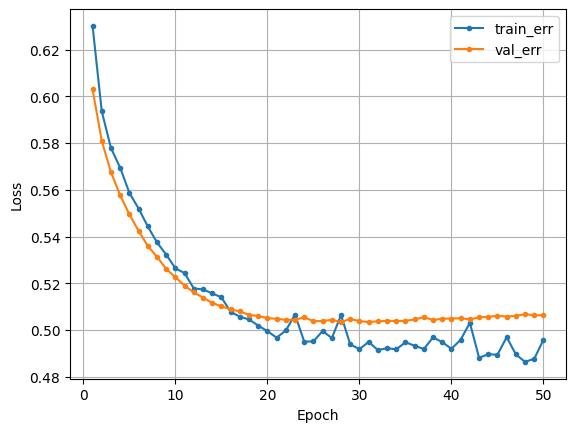

In [19]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

In [20]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

* **[회귀와 다른점]** 예측결과는 0 ~ 1 사이의 확률값
    * 확률값을 0, 1로 변환 필요
    * np.where(조건문, True일때 값, False일때 값)

In [21]:
pred.numpy()[:5]

array([[0.69050807],
       [0.1508142 ],
       [0.20422715],
       [0.17259547],
       [0.69894314]], dtype=float32)

In [22]:
pred = np.where(pred.numpy() > .5, 1, 0)
pred[:5]

array([[1],
       [0],
       [0],
       [0],
       [1]])

* confusion matrix

In [23]:
confusion_matrix(y_val_ts.numpy(), pred)

array([[141,  29],
       [ 31,  67]])

* classification_report

In [24]:
print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.82      0.83      0.82       170
         1.0       0.70      0.68      0.69        98

    accuracy                           0.78       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.78      0.78      0.78       268



## **4.딥러닝2 : 전체 feature**
* 이제 전체 데이터를 가지고 모델링을 시도해 보겠습니다.


### (1) 데이터 전처리

* 데이터 준비

In [25]:
target = 'Survived'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

* 가변수화

In [26]:
cat_cols = ['Pclass','Sex', 'Embarked']
x = pd.get_dummies(x, columns = cat_cols, drop_first = True)

* 데이터분할

In [27]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3, random_state = 20)

* 스케일링

In [28]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

### (2) 모델링

#### 1) 딥러닝을 위한 준비작업

* make_DataLoader

In [29]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [30]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f"Shape of x [rows, columns]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [rows, columns]: torch.Size([32, 8])
Shape of y: torch.Size([32, 1]) torch.float32


#### 2) 모델 선언

In [33]:
n_feature = x.shape[1]

# 모델 구조 설계
model = nn.Sequential(
                nn.Linear(n_feature, 1),
                nn.Sigmoid()                # 시그모이드 활성화 함수 추가
        ).to(device)

print(model)

Sequential(
  (0): Linear(in_features=8, out_features=1, bias=True)
  (1): Sigmoid()
)


* Loss function과 Optimizer

In [34]:
loss_fn = nn.BCELoss()           # Bineary Cross Entropy
optimizer = Adam(model.parameters(), lr=0.01)

#### 3) 학습

In [37]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for t in range(epochs ):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.688727, val loss : 0.638112
Epoch 2, train loss : 0.642443, val loss : 0.609871
Epoch 3, train loss : 0.615446, val loss : 0.591747
Epoch 4, train loss : 0.596047, val loss : 0.577520
Epoch 5, train loss : 0.577834, val loss : 0.563586
Epoch 6, train loss : 0.562108, val loss : 0.552331
Epoch 7, train loss : 0.552381, val loss : 0.542246
Epoch 8, train loss : 0.538503, val loss : 0.534940
Epoch 9, train loss : 0.535393, val loss : 0.527822
Epoch 10, train loss : 0.523844, val loss : 0.522849
Epoch 11, train loss : 0.517460, val loss : 0.516369
Epoch 12, train loss : 0.510412, val loss : 0.512543
Epoch 13, train loss : 0.501681, val loss : 0.507811
Epoch 14, train loss : 0.495517, val loss : 0.504654
Epoch 15, train loss : 0.493582, val loss : 0.501488
Epoch 16, train loss : 0.490785, val loss : 0.499044
Epoch 17, train loss : 0.487453, val loss : 0.496993
Epoch 18, train loss : 0.483958, val loss : 0.494368
Epoch 19, train loss : 0.483633, val loss : 0.492836
Ep

* 학습된 파라미터 확인

In [38]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-0.7326,  3.7007, -0.8545, -0.2197, -1.3407, -2.3273,  0.4852, -0.1510]])
Parameter: 0.bias, Value: tensor([1.8261])


* 학습 곡선

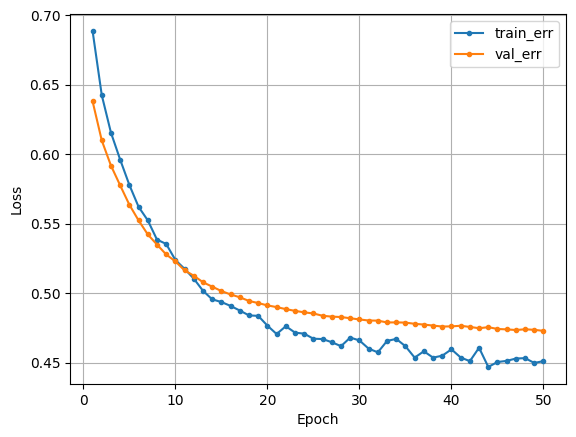

In [39]:
dl_learning_curve(tr_loss_list, val_loss_list)

#### 4) 모델 평가

In [40]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

In [41]:
pred = np.where(pred.numpy() > .5, 1, 0)

* confusion matrix

In [42]:
confusion_matrix(y_val_ts.numpy(), pred)

array([[144,  26],
       [ 33,  65]])

* classification_report

In [43]:
print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.81      0.85      0.83       170
         1.0       0.71      0.66      0.69        98

    accuracy                           0.78       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.78      0.78      0.78       268



----

## **5.딥러닝3 : hidden layer**
* 이제 레이어를 추가해 보겠습니다.


### (1) 모델 선언

In [44]:
n_feature = x.shape[1]

# 모델 구조 설계
model = nn.Sequential(
            nn.Linear(n_feature, 5),    # 은닉층
            nn.ReLU(),                          # 은닉층의 활성화함수
            nn.Linear(5, 1),            # 출력층
            nn.Sigmoid()                            # 출력층의 활성화함수
        ).to(device)

print(model)

Sequential(
  (0): Linear(in_features=8, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
  (3): Sigmoid()
)


* Loss function과 Optimizer

In [45]:
loss_fn =  nn.BCELoss()         # Bineary Cross Entropy
optimizer = Adam(model.parameters(), lr=0.01)

### (2) 학습

In [46]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for t in range(epochs ):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.671571, val loss : 0.642049
Epoch 2, train loss : 0.641997, val loss : 0.612173
Epoch 3, train loss : 0.612917, val loss : 0.580513
Epoch 4, train loss : 0.577215, val loss : 0.552719
Epoch 5, train loss : 0.549982, val loss : 0.535701
Epoch 6, train loss : 0.523270, val loss : 0.520097
Epoch 7, train loss : 0.511056, val loss : 0.508643
Epoch 8, train loss : 0.491780, val loss : 0.491398
Epoch 9, train loss : 0.475627, val loss : 0.483608
Epoch 10, train loss : 0.459391, val loss : 0.474568
Epoch 11, train loss : 0.461768, val loss : 0.472177
Epoch 12, train loss : 0.455679, val loss : 0.470963
Epoch 13, train loss : 0.447380, val loss : 0.471780
Epoch 14, train loss : 0.442848, val loss : 0.467554
Epoch 15, train loss : 0.441999, val loss : 0.468244
Epoch 16, train loss : 0.440438, val loss : 0.470122
Epoch 17, train loss : 0.447495, val loss : 0.467621
Epoch 18, train loss : 0.449400, val loss : 0.466614
Epoch 19, train loss : 0.441235, val loss : 0.469247
Ep

* 학습된 파라미터 확인

In [47]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-0.3275, -0.0205, -0.2862, -0.3436, -0.0815,  0.2664,  0.0460, -0.2775],
        [ 1.1356, -0.5265,  0.5996,  0.2801,  1.1476,  1.0912,  0.0439,  0.1488],
        [-0.1567, -0.1864, -0.0396, -0.0021,  0.0183, -0.2602,  0.0424, -0.0991],
        [-0.1798,  1.9891, -0.4431, -0.0027, -0.1656, -0.1428,  0.4835, -0.0252],
        [ 1.2842, -0.7491,  0.6932,  0.2602,  0.4674,  0.9061,  0.2581,  0.0654]])
Parameter: 0.bias, Value: tensor([-0.2186, -0.4801, -0.1187,  1.3112, -0.4307])
Parameter: 2.weight, Value: tensor([[-0.3665, -0.9724,  0.0581,  1.2776, -1.5872]])
Parameter: 2.bias, Value: tensor([0.9299])


* 학습 곡선

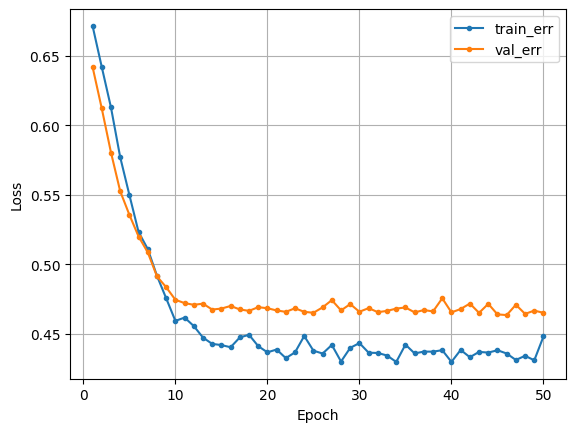

In [48]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

In [50]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

In [52]:
pred = np.where( pred.numpy() > .5, 1, 0)

* confusion matrix

In [53]:
confusion_matrix(y_val_ts.numpy(), pred)

array([[144,  26],
       [ 35,  63]])

* classification_report

In [54]:
print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.80      0.85      0.83       170
         1.0       0.71      0.64      0.67        98

    accuracy                           0.77       268
   macro avg       0.76      0.74      0.75       268
weighted avg       0.77      0.77      0.77       268



## **6.실습**

### (1) 실습1

* 다음의 구조를 보고 모델을 설계하시오.

        Sequential(
        (0): Linear(in_features=8, out_features=10, bias=True)
        (1): ReLU()
        (2): Linear(in_features=10, out_features=5, bias=True)
        (3): ReLU()
        (4): Linear(in_features=5, out_features=1, bias=True)
        (5): Sigmoid()
        )

In [61]:
n_feature = x.shape[1]
model1 = nn.Sequential(
    nn.Linear(n_feature, 10),
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 1),
    nn.Sigmoid()
)

In [62]:
loss_fn = nn.BCELoss()
optimizer = Adam(model1.parameters(), lr = 0.01)

In [63]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for i in range(epochs):
  tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
  val_loss,_ = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 50, train loss : 0.659418, val loss : 0.611249
Epoch 50, train loss : 0.558163, val loss : 0.500095
Epoch 50, train loss : 0.458014, val loss : 0.477564
Epoch 50, train loss : 0.438600, val loss : 0.484892
Epoch 50, train loss : 0.434490, val loss : 0.480416
Epoch 50, train loss : 0.428025, val loss : 0.471231
Epoch 50, train loss : 0.429681, val loss : 0.468076
Epoch 50, train loss : 0.431302, val loss : 0.465308
Epoch 50, train loss : 0.421207, val loss : 0.459492
Epoch 50, train loss : 0.422884, val loss : 0.464836
Epoch 50, train loss : 0.427796, val loss : 0.459299
Epoch 50, train loss : 0.416955, val loss : 0.461835
Epoch 50, train loss : 0.425718, val loss : 0.464364
Epoch 50, train loss : 0.414011, val loss : 0.460349
Epoch 50, train loss : 0.411983, val loss : 0.462664
Epoch 50, train loss : 0.419317, val loss : 0.455606
Epoch 50, train loss : 0.421265, val loss : 0.457707
Epoch 50, train loss : 0.411897, val loss : 0.455478
Epoch 50, train loss : 0.409528, val loss : 0.

In [64]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[ 5.2747e-01, -7.6833e-01,  7.9417e-01, -9.7362e-02,  1.8212e-01,
          3.4232e-01,  6.3494e-01,  1.4189e-01],
        [-1.0849e+00, -5.5003e-01,  1.4581e-01, -1.0695e-01, -5.0579e-01,
          4.5966e-01, -8.8025e-01, -7.0489e-01],
        [ 4.7939e-02, -2.2500e-01, -3.7226e-03,  5.8346e-02,  6.2757e-02,
         -7.1254e-02, -2.3266e-01,  2.2787e-01],
        [ 1.6328e-01,  3.5159e+00,  8.9633e-01,  1.1124e+00,  5.4564e-04,
         -1.6485e+00,  3.5603e-01, -1.1062e+00],
        [-1.7087e+00, -2.4000e+00,  1.7696e+00,  5.3853e-01,  3.5631e-01,
          6.7294e-01,  6.6917e-01, -5.5944e-01],
        [ 1.0197e+00,  1.8229e-01, -2.1370e+00,  8.2784e-01, -4.6463e-01,
          5.5799e-01, -1.5305e-01, -5.4282e-01],
        [ 1.0803e+00, -1.0685e+00,  7.5657e-01,  1.2042e-01,  6.5606e-01,
          3.6278e-01,  4.1024e-01, -3.8156e-01],
        [ 1.3861e+00, -1.5506e-03,  7.7232e-01,  6.2595e-02,  7.1976e-01,
          3.9129e-01,  8.4102e-02,  5

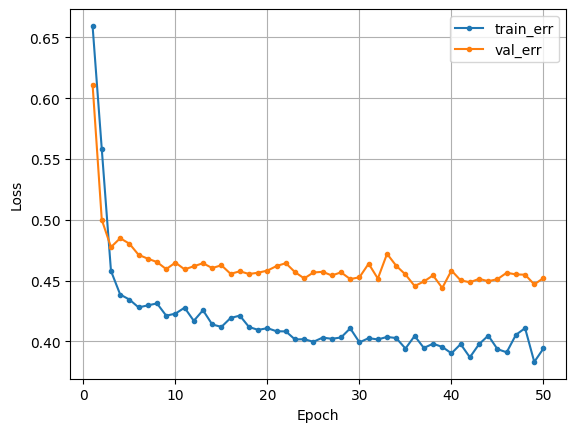

In [65]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (2) 실습2

* 이번에는 여러분이 원하는 대로 설계하고, 학습해 봅시다.


In [68]:
n_feature = x.shape[1]
model2 = nn.Sequential(
    nn.Linear(n_feature, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

In [69]:
loss_fn = nn.BCELoss()
optimizer = Adam(model2.parameters(), lr = 0.01)

In [70]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for i in range(epochs):
  tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
  val_loss,_ = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 50, train loss : 0.660959, val loss : 0.584733
Epoch 50, train loss : 0.565848, val loss : 0.525708
Epoch 50, train loss : 0.497667, val loss : 0.485722
Epoch 50, train loss : 0.460238, val loss : 0.471494
Epoch 50, train loss : 0.450550, val loss : 0.478394
Epoch 50, train loss : 0.451366, val loss : 0.473252
Epoch 50, train loss : 0.438466, val loss : 0.456100
Epoch 50, train loss : 0.425802, val loss : 0.459426
Epoch 50, train loss : 0.423019, val loss : 0.478578
Epoch 50, train loss : 0.412656, val loss : 0.466790
Epoch 50, train loss : 0.423726, val loss : 0.460340
Epoch 50, train loss : 0.408488, val loss : 0.458447
Epoch 50, train loss : 0.416544, val loss : 0.460591
Epoch 50, train loss : 0.416751, val loss : 0.456860
Epoch 50, train loss : 0.410128, val loss : 0.451357
Epoch 50, train loss : 0.413078, val loss : 0.453593
Epoch 50, train loss : 0.401504, val loss : 0.456833
Epoch 50, train loss : 0.416462, val loss : 0.459910
Epoch 50, train loss : 0.408865, val loss : 0.

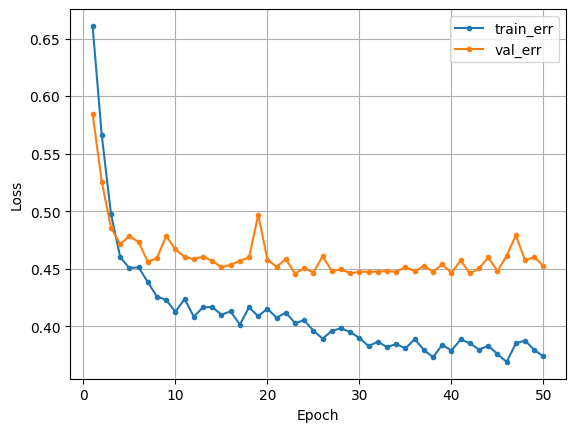

In [71]:
dl_learning_curve(tr_loss_list, val_loss_list)